In [12]:
import zipfile
from tqdm.notebook import tqdm

zip_path = '/content/raw_data/brats20-dataset-training-validation.zip'
extract_path = '/content/raw_data'

with zipfile.ZipFile(zip_path, 'r') as zf:
    members = zf.namelist()
    for member in tqdm(members, desc="Extracting"):
        zf.extract(member, extract_path)

import os
os.remove(zip_path)

Extracting:   0%|          | 0/2349 [00:00<?, ?it/s]

In [13]:
import numpy as np, nibabel as nib, glob, os

train_root = '/content/raw_data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'
patient_dirs = sorted(glob.glob(f'{train_root}/BraTS20_Training_*'))

out_img_dir = '/content/local_data/images'
out_mask_dir = '/content/local_data/masks'
os.makedirs(out_img_dir, exist_ok=True)
os.makedirs(out_mask_dir, exist_ok=True)

def process_patient(patient_dir):
    patient_id = os.path.basename(patient_dir)
    flair_path = f'{patient_dir}/{patient_id}_flair.nii'
    seg_path = f'{patient_dir}/{patient_id}_seg.nii'
    flair = nib.load(flair_path).get_fdata()
    seg = nib.load(seg_path).get_fdata()
    saved = 0
    for i in range(flair.shape[2]):
        img_slice = flair[:, :, i]
        mask_slice = seg[:, :, i]
        if img_slice.max() == 0:
            continue
        img_slice = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)
        mask_slice = (mask_slice > 0).astype(np.uint8)
        np.save(f'{out_img_dir}/{patient_id}_slice{i:03d}.npy', img_slice.astype(np.float32))
        np.save(f'{out_mask_dir}/{patient_id}_slice{i:03d}.npy', mask_slice)
        saved += 1
    return saved

from tqdm.notebook import tqdm
skipped = []
total_saved = 0
for pdir in tqdm(patient_dirs, desc="Slicing patients"):
    try:
        total_saved += process_patient(pdir)
    except FileNotFoundError:
        skipped.append(os.path.basename(pdir))

print(f"Done. Saved {total_saved} slices. Skipped: {skipped}")

Slicing patients:   0%|          | 0/369 [00:00<?, ?it/s]

Done. Saved 50706 slices. Skipped: ['BraTS20_Training_355']


In [15]:
import os, glob, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
print("Using device:", device)

img_dir = '/content/local_data/images'
mask_dir = '/content/local_data/masks'
print("Total images:", len(glob.glob(f'{img_dir}/*.npy')))

Using device: cuda
Total images: 50706


In [16]:
class BratsSliceDataset(Dataset):
    def __init__(self, img_dir, mask_dir, patient_ids):
        all_imgs = sorted(glob.glob(f'{img_dir}/*.npy'))
        self.img_paths = [p for p in all_imgs if os.path.basename(p).split('_slice')[0] in patient_ids]
        self.mask_dir = mask_dir
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        fname = os.path.basename(img_path)
        mask_path = os.path.join(self.mask_dir, fname)
        img = torch.from_numpy(np.load(img_path)).unsqueeze(0).float()
        mask = torch.from_numpy(np.load(mask_path)).unsqueeze(0).float()
        return img, mask

all_patient_ids = sorted(set(os.path.basename(f).split('_slice')[0] for f in glob.glob(f'{img_dir}/*.npy')))
random.seed(42)
random.shuffle(all_patient_ids)
split_idx = int(0.8 * len(all_patient_ids))
train_patients = set(all_patient_ids[:split_idx])
val_patients = set(all_patient_ids[split_idx:])

train_dataset = BratsSliceDataset(img_dir, mask_dir, train_patients)
val_dataset = BratsSliceDataset(img_dir, mask_dir, val_patients)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train slices: {len(train_dataset)}, Val slices: {len(val_dataset)}")

Train slices: 40527, Val slices: 10179


In [18]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        ch = in_channels
        for f in features:
            self.encoder.append(DoubleConv(ch, f))
            ch = f
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        for f in reversed(features):
            self.decoder.append(nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2))
            self.decoder.append(DoubleConv(f * 2, f))
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.encoder:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.decoder), 2):
            x = self.decoder[idx](x)
            skip = skip_connections[idx // 2]
            if x.shape != skip.shape:
                x = nn.functional.interpolate(x, size=skip.shape[2:])
            x = torch.cat((skip, x), dim=1)
            x = self.decoder[idx + 1](x)
        return self.final_conv(x)

In [19]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, preds, targets):
        preds = torch.sigmoid(preds).view(-1)
        targets = targets.view(-1)
        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)
        return 1 - dice

def dice_score(preds, targets, threshold=0.5, smooth=1e-6):
    preds = (torch.sigmoid(preds) > threshold).float().view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    return (2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)

def iou_score(preds, targets, threshold=0.5, smooth=1e-6):
    preds = (torch.sigmoid(preds) > threshold).float().view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return (intersection + smooth) / (union + smooth)

scaler = torch.cuda.amp.GradScaler()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc="Training", leave=False)
    for imgs, masks in pbar:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            preds = model(imgs)
            loss = criterion(preds, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss, total_dice, total_iou = 0, 0, 0
    pbar = tqdm(loader, desc="Validating", leave=False)
    with torch.no_grad():
        for imgs, masks in pbar:
            imgs, masks = imgs.to(device), masks.to(device)
            with torch.cuda.amp.autocast():
                preds = model(imgs)
                loss = criterion(preds, masks)
            total_loss += loss.item()
            total_dice += dice_score(preds, masks).item()
            total_iou += iou_score(preds, masks).item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")
    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n

/tmp/ipykernel_4850/3513986683.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [20]:
model = UNet(in_channels=1, out_channels=1).to(device)
criterion = DiceLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
print(model)

UNet(
  (encoder): ModuleList(
    (0): DoubleConv(
      (double_conv): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): DoubleConv(
      (double_conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (2): Doub

In [21]:
model = UNet(in_channels=1, out_channels=1).to(device)
criterion = DiceLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
print(model)

UNet(
  (encoder): ModuleList(
    (0): DoubleConv(
      (double_conv): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): DoubleConv(
      (double_conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (2): Doub

In [31]:
class BratsSliceDataset(Dataset):
    def __init__(self, img_dir, mask_dir, patient_ids):
        all_imgs = sorted(glob.glob(f'{img_dir}/*.npy'))
        self.img_paths = [p for p in all_imgs if os.path.basename(p).split('_slice')[0] in patient_ids]
        self.mask_dir = mask_dir
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, idx):
        try:
            img_path = self.img_paths[idx]
            fname = os.path.basename(img_path)
            mask_path = os.path.join(self.mask_dir, fname)
            img = torch.from_numpy(np.load(img_path)).unsqueeze(0).float()
            mask = torch.from_numpy(np.load(mask_path)).unsqueeze(0).float()
            return img, mask
        except Exception:
            return self.__getitem__((idx + 1) % len(self))

In [32]:
train_dataset = BratsSliceDataset(img_dir, mask_dir, train_patients)
val_dataset = BratsSliceDataset(img_dir, mask_dir, val_patients)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

Train: 40498, Val: 10179


In [33]:
start = time.time()
train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
val_loss, val_dice, val_iou = validate(model, val_loader, criterion, device)
elapsed = time.time() - start
print(f"1 epoch took {elapsed/60:.1f} min | train_loss={train_loss:.4f} val_dice={val_dice:.4f}")

Training:   0%|          | 0/317 [00:00<?, ?it/s]

/tmp/ipykernel_4850/3513986683.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Validating:   0%|          | 0/80 [00:00<?, ?it/s]

/tmp/ipykernel_4850/3513986683.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


1 epoch took 3.5 min | train_loss=0.8280 val_dice=0.6382


In [34]:
checkpoint_path = '/content/local_data/unet_brats_baseline.pth'
drive_backup_path = '/content/drive/MyDrive/brats_project/unet_brats_baseline.pth'

history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}
best_dice = 0.0
num_epochs = 20

for epoch in range(num_epochs):
    start = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_dice, val_iou = validate(model, val_loader, criterion, device)
    elapsed = time.time() - start

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)

    print(f"Epoch {epoch+1}/{num_epochs} ({elapsed/60:.1f} min) | "
          f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
          f"val_dice={val_dice:.4f} val_iou={val_iou:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), checkpoint_path)
        import shutil
        shutil.copy(checkpoint_path, drive_backup_path)
        print(f"  -> New best model saved (dice={best_dice:.4f}), backed up to Drive")

print(f"\nTraining complete. Best val_dice: {best_dice:.4f}")

Training:   0%|          | 0/317 [00:00<?, ?it/s]

/tmp/ipykernel_4850/3513986683.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Validating:   0%|          | 0/80 [00:00<?, ?it/s]

/tmp/ipykernel_4850/3513986683.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/20 (2.6 min) | train_loss=0.6049 val_loss=0.5596 val_dice=0.8266 val_iou=0.7280
  -> New best model saved (dice=0.8266), backed up to Drive


...

Validating:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 19/20 (2.6 min) | train_loss=0.0435 val_loss=0.1505 val_dice=0.8515 val_iou=0.7627


Training:   0%|          | 0/317 [00:00<?, ?it/s]

Validating:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 20/20 (2.6 min) | train_loss=0.0429 val_loss=0.1394 val_dice=0.8623 val_iou=0.7752
  -> New best model saved (dice=0.8623), backed up to Drive

Training complete. Best val_dice: 0.8623


In [35]:
print(f"Best val_dice achieved: {best_dice:.4f}")
print(f"Final epoch val_dice: {history['val_dice'][-1]:.4f}")
print(f"Final epoch val_iou: {history['val_iou'][-1]:.4f}")

Best val_dice achieved: 0.8623
Final epoch val_dice: 0.8623
Final epoch val_iou: 0.7752


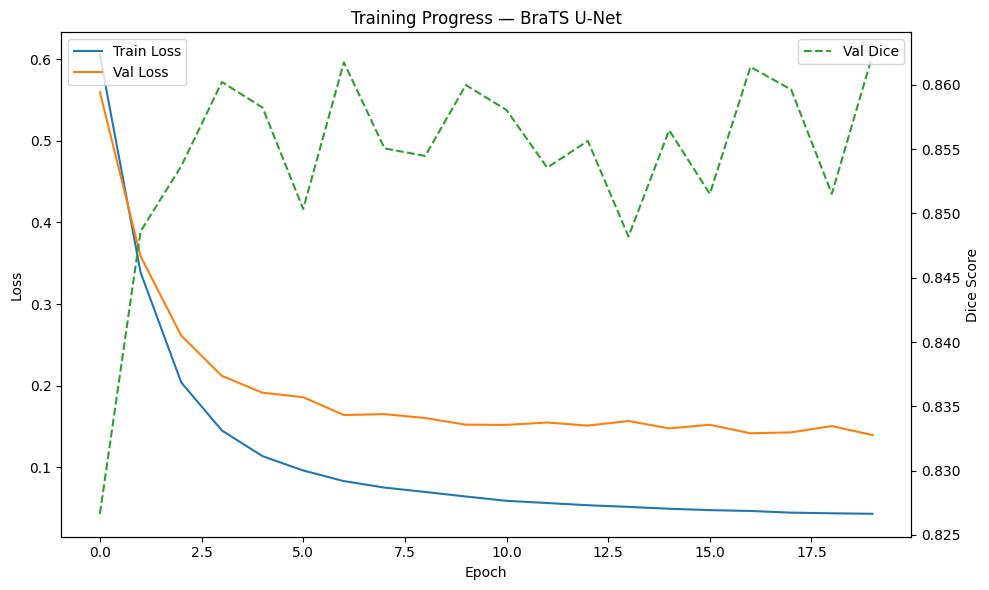

In [36]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(history['train_loss'], label='Train Loss', color='tab:blue')
ax1.plot(history['val_loss'], label='Val Loss', color='tab:orange')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(history['val_dice'], label='Val Dice', color='tab:green', linestyle='--')
ax2.set_ylabel('Dice Score'); ax2.legend(loc='upper right')

plt.title('Training Progress — BraTS U-Net')
plt.tight_layout()
plt.savefig('/content/local_data/training_plot.png', dpi=150, bbox_inches='tight')
plt.show()

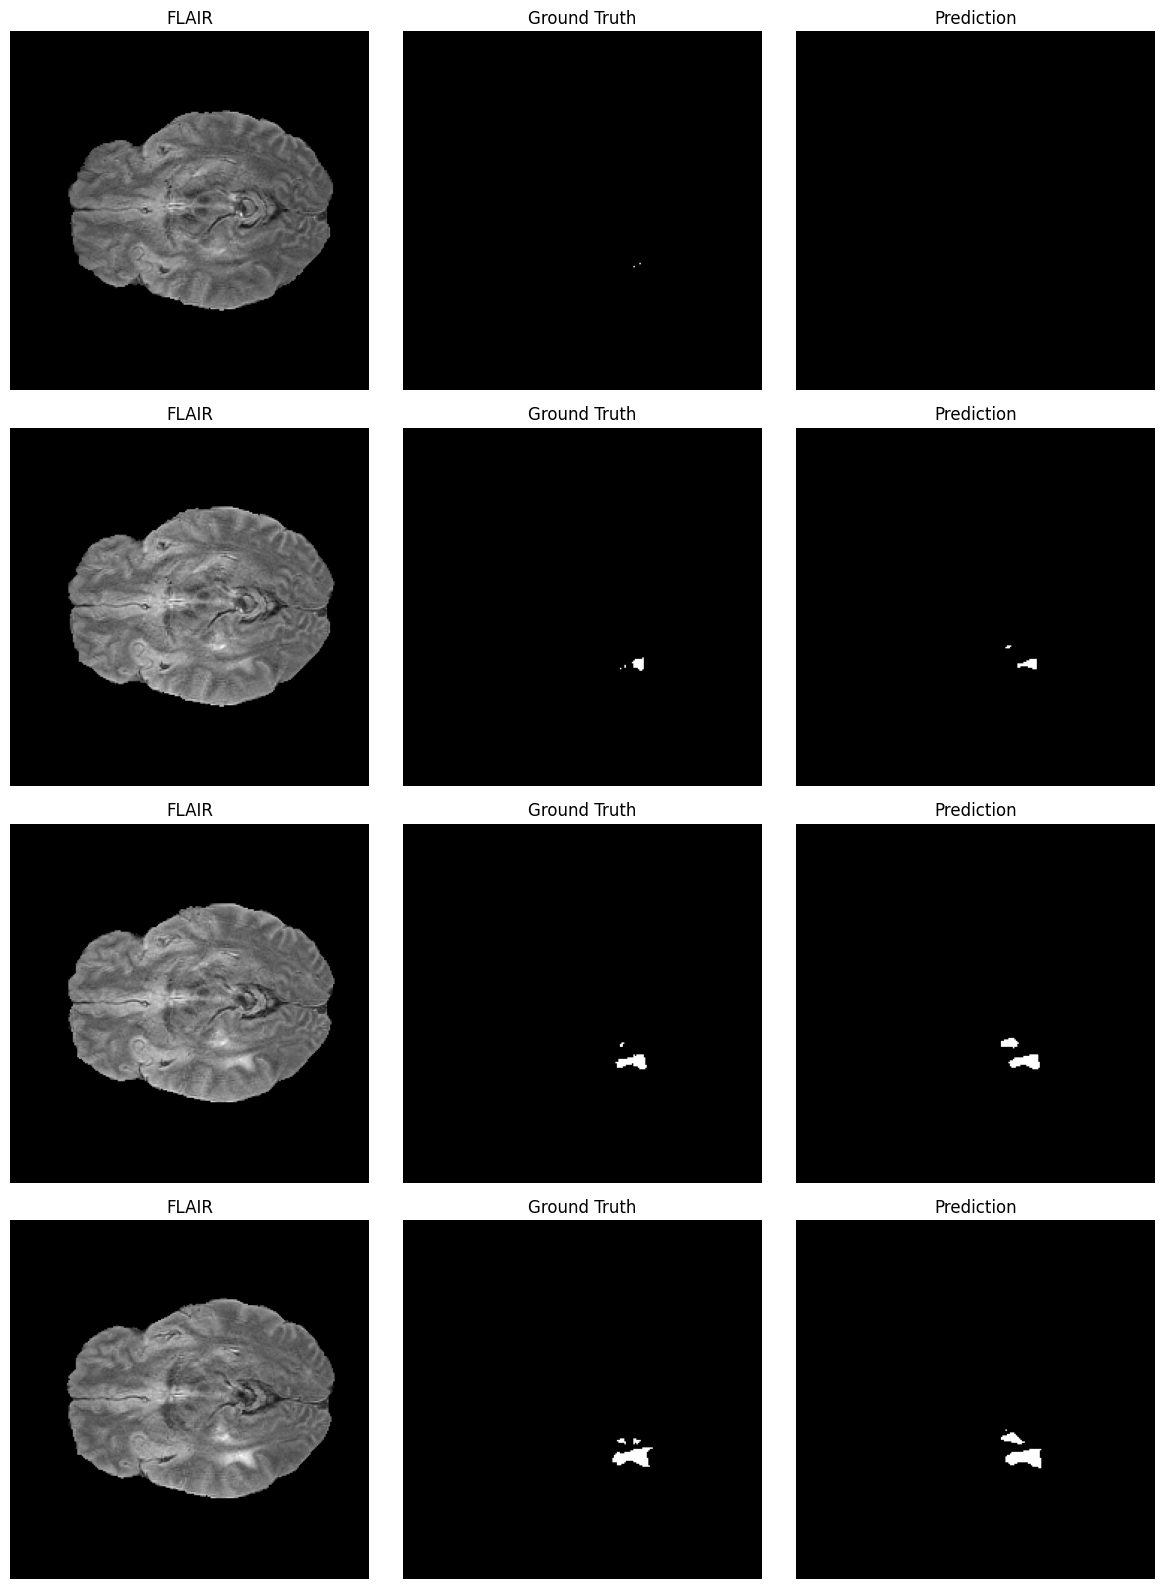

In [37]:
model.eval()
found_tumor_batch = None
for imgs, masks in val_loader:
    if masks.sum() > 0:
        found_tumor_batch = (imgs, masks)
        break

imgs, masks = found_tumor_batch
imgs, masks = imgs.to(device), masks.to(device)

with torch.no_grad():
    with torch.amp.autocast('cuda'):
        preds = torch.sigmoid(model(imgs)) > 0.5

imgs_np = imgs.cpu().numpy()
masks_np = masks.cpu().numpy()
preds_np = preds.float().cpu().numpy()
tumor_indices = [i for i in range(len(masks_np)) if masks_np[i].sum() > 0][:4]

fig, axes = plt.subplots(len(tumor_indices), 3, figsize=(12, 4*len(tumor_indices)))
for row, i in enumerate(tumor_indices):
    axes[row, 0].imshow(imgs_np[i, 0], cmap='gray'); axes[row, 0].set_title('FLAIR')
    axes[row, 1].imshow(masks_np[i, 0], cmap='gray'); axes[row, 1].set_title('Ground Truth')
    axes[row, 2].imshow(preds_np[i, 0], cmap='gray'); axes[row, 2].set_title('Prediction')
    for j in range(3): axes[row, j].axis('off')
plt.tight_layout()
plt.savefig('/content/local_data/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
from google.colab import files
files.download('/content/local_data/unet_brats_baseline.pth')
files.download('/content/local_data/training_plot.png')
files.download('/content/local_data/sample_predictions.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
import shutil
shutil.copy('/content/local_data/training_plot.png', '/content/drive/MyDrive/brats_project/training_plot.png')
shutil.copy('/content/local_data/sample_predictions.png', '/content/drive/MyDrive/brats_project/sample_predictions.png')

'/content/drive/MyDrive/brats_project/sample_predictions.png'